In [27]:
import numpy as np
import swarmParameters as swm
import crossSections as crs
from forward_propagater import getReactionFromBolsigOutput
import re
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

In [52]:
crsFile = 'crs/BSR.1s.step-excite.txt'
crsSet = crs.multipleCrossSections(crsFile)
tmp = 0
collisionDict = {}
for it, c in enumerate(crsSet.crs):
    if (crs.typeDictI2S[c.colType] == 'EXCITATION'):
        tmp += 1
        reactant, direction, product = re.split("( -> )", c.colName)
        deltaE = 1.0e-2 * round(1.0e2 * c.deltaE)
        label = 'C%d' % (it+1)
        print("%s: %s -> %s" % (label, reactant, product))
        print("  DeltaE = {0:.6e}".format(deltaE))
        collisionDict[label] = {'reactant': reactant, 'product': product, 'deltaE': deltaE}

print(tmp)
print(len(collisionDict))

C2: Ar -> Ar5
  DeltaE = 1.155000e+01
C3: Ar -> Ar4
  DeltaE = 1.162000e+01
C4: Ar -> Ar3
  DeltaE = 1.172000e+01
C5: Ar -> Ar2
  DeltaE = 1.183000e+01
C6: Ar -> Ar(4p[1/2]1)
  DeltaE = 1.307000e+01
C7: Ar -> Ar(4p[5/2]3)
  DeltaE = 1.320000e+01
C8: Ar -> Ar(4p[5/2]2)
  DeltaE = 1.323000e+01
C9: Ar -> Ar(4p[3/2]1)
  DeltaE = 1.328000e+01
C10: Ar -> Ar(4p[3/2]2)
  DeltaE = 1.330000e+01
C11: Ar -> Ar(4p[1/2]0)
  DeltaE = 1.340000e+01
C12: Ar -> Ar(4p'[3/2]1)
  DeltaE = 1.340000e+01
C13: Ar -> Ar(4p'[3/2]2)
  DeltaE = 1.342000e+01
C14: Ar -> Ar(4p'[1/2]1)
  DeltaE = 1.344000e+01
C15: Ar -> Ar(4p'[1/2]0)
  DeltaE = 1.359000e+01
C16: Ar -> Ar(3d[1/2]0)
  DeltaE = 1.407000e+01
C17: Ar -> Ar(3d[1/2]1)
  DeltaE = 1.408000e+01
C18: Ar -> Ar(3d[3/2]2)
  DeltaE = 1.410000e+01
C19: Ar -> Ar(3d[7/2]4)
  DeltaE = 1.415000e+01
C20: Ar -> Ar(5s[3/2]2)
  DeltaE = 1.416000e+01
C21: Ar -> Ar(3d[7/2]3)
  DeltaE = 1.416000e+01
C22: Ar -> Ar(5s[3/2]1)
  DeltaE = 1.418000e+01
C23: Ar -> Ar(3d[5/2]2)
  DeltaE

In [78]:
fwdFile = 'output/datasets/BSR-step-excite.forward.dat'
rvsFile = 'output/datasets/BSR-step-excite.reverse.dat'
fwdRates = swm.bolsigOutput(fwdFile)
rvsRates = swm.bolsigOutput(rvsFile)
for c in fwdRates.outputs:
    deltaE = fwdRates.outputs[c].deltaE
    print("%s, %s" % (fwdRates.outputs[c].inputName, fwdRates.outputs[c].outputName))
    print("{0:s}\t{1:s}\t{2:.6e}".format(fwdRates.outputs[c].species, fwdRates.outputs[c].collisionType, deltaE))
#         print("Energy: %.4E, Reaction: %s -> %s" % (deltaE, collisionDict[deltaE]['reactant'], collisionDict[deltaE]['product']))


E/N (Td), Electric field / N (Td)
		0.000000e+00
E/N (Td), Mean energy (eV)
		0.000000e+00
E/N (Td), Mobility *N (1/m/V/s)
		0.000000e+00
E/N (Td), Diffusion coefficient *N (1/m/s)
		0.000000e+00
E/N (Td), Energy mobility *N (1/m/V/s)
		0.000000e+00
E/N (Td), Energy diffusion coef. D*N (1/m/s)
		0.000000e+00
E/N (Td), Total collision freq. /N (m3/s)
		0.000000e+00
E/N (Td), Momentum frequency /N (m3/s)
		0.000000e+00
E/N (Td), e-i momentum frequency /N (m3/s)
		0.000000e+00
E/N (Td), Total ionization freq. /N (m3/s)
		0.000000e+00
E/N (Td), Townsend ioniz. coef. alpha/N (m2)
		0.000000e+00
E/N (Td), Power /N (eV m3/s)
		0.000000e+00
E/N (Td), Elastic power loss /N (eV m3/s)
		0.000000e+00
E/N (Td), Inelastic power loss /N (eV m3/s)
		0.000000e+00
E/N (Td), Growth power /N (eV m3/s)
		0.000000e+00
E/N (Td), e-i power loss /N (eV m3/s)
		0.000000e+00
E/N (Td), Coulomb logarithm
		0.000000e+00
E/N (Td), Maximum energy
		0.000000e+00
E/N (Td), # of iterations
		0.000000e+00
E/N (Td), # of 

In [79]:
for c in fwdRates.outputs:
    label = fwdRates.typeDictI2S[c]
    print(label)
    if (fwdRates.outputs[c].collisionType == 'Excitation'):
        print("%s -> %s (%.4E)" % (collisionDict[label]['reactant'], collisionDict[label]['product'], collisionDict[label]['deltaE']))
        deltaE = fwdRates.outputs[c].deltaE
        print("{0:s}\t{1:s}\t{2:.6e}".format(fwdRates.outputs[c].species, fwdRates.outputs[c].collisionType, deltaE))
        print("Difference: %.5E" % abs(deltaE - collisionDict[label]['deltaE']))

Electric field / N (Td)
Mean energy (eV)
Mobility *N (1/m/V/s)
Diffusion coefficient *N (1/m/s)
Energy mobility *N (1/m/V/s)
Energy diffusion coef. D*N (1/m/s)
Total collision freq. /N (m3/s)
Momentum frequency /N (m3/s)
e-i momentum frequency /N (m3/s)
Total ionization freq. /N (m3/s)
Townsend ioniz. coef. alpha/N (m2)
Power /N (eV m3/s)
Elastic power loss /N (eV m3/s)
Inelastic power loss /N (eV m3/s)
Growth power /N (eV m3/s)
e-i power loss /N (eV m3/s)
Coulomb logarithm
Maximum energy
# of iterations
# of grid trials
C1
C2
Ar -> Ar5 (1.1550E+01)
Ar	Excitation	1.155000e+01
Difference: 0.00000E+00
C3
Ar -> Ar4 (1.1620E+01)
Ar	Excitation	1.162000e+01
Difference: 1.77636E-15
C4
Ar -> Ar3 (1.1720E+01)
Ar	Excitation	1.172000e+01
Difference: 0.00000E+00
C5
Ar -> Ar2 (1.1830E+01)
Ar	Excitation	1.183000e+01
Difference: 0.00000E+00
C6
Ar -> Ar(4p[1/2]1) (1.3070E+01)
Ar	Excitation	1.307000e+01
Difference: 0.00000E+00
C7
Ar -> Ar(4p[5/2]3) (1.3200E+01)
Ar	Excitation	1.320000e+01
Difference: 1.

Text(0.5, 1.0, 'E + AR(4p) -> E + Ar(r)')

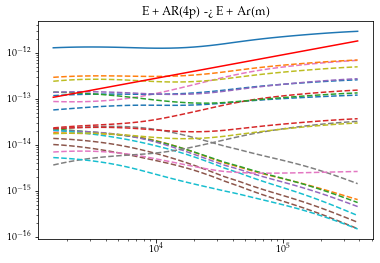

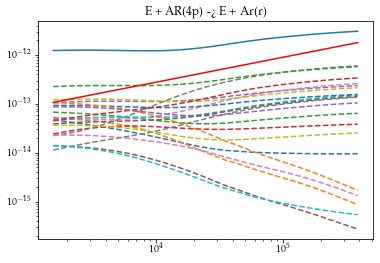

In [88]:
qe = 1.60217663e-19 # C
kB = 1.380649e-23 # m2 kg s-2 K-1
NA = 6.0221408e23    # mol-1
eV = qe / kB    # K
Ue = rvsRates.outputs[3].data[:,1]
Te = Ue / 1.5 * eV
rxn20 = np.zeros(Te.shape)
rxn19 = np.zeros(Te.shape)

plt.figure(1)
for c in rvsRates.outputs:
    label = rvsRates.typeDictI2S[c]
    if (rvsRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] == 'Ar5') or (collisionDict[label]['reactant'] == 'Ar3'):
            if (collisionDict[label]['product'][:5] == 'Ar(4p'):
                plt.loglog(Te, rvsRates.outputs[c].data[:,1],'--')
                rxn20 += rvsRates.outputs[c].data[:,1]
plt.loglog(Te, rxn20, '-')
plt.loglog(Te, 3.0e-13 * (Ue / 1.5) ** 0.51, '-r')
plt.title('E + AR(4p) -> E + Ar(m)')

plt.figure(2)
for c in rvsRates.outputs:
    label = rvsRates.typeDictI2S[c]
    if (rvsRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] == 'Ar4') or (collisionDict[label]['reactant'] == 'Ar2'):
            if (collisionDict[label]['product'][:5] == 'Ar(4p'):
                plt.loglog(Te, rvsRates.outputs[c].data[:,1],'--')
                rxn19 += rvsRates.outputs[c].data[:,1]
plt.loglog(Te, rxn19, '-')
plt.loglog(Te, 3.0e-13 * (Ue / 1.5) ** 0.51, '-r')
plt.title('E + AR(4p) -> E + Ar(r)')

Text(0.5, 1.0, 'E + AR(r) -> E + Ar(4p)')

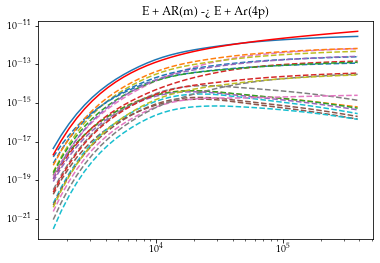

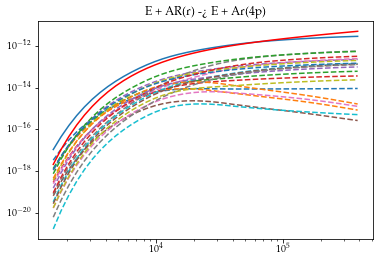

In [82]:
Ue = fwdRates.outputs[3].data[:,1]
Te = Ue / 1.5 * eV
rxn17 = np.zeros(Te.shape)
rxn23 = np.zeros(Te.shape)

plt.figure(1)
for c in fwdRates.outputs:
    label = fwdRates.typeDictI2S[c]
    if (fwdRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] == 'Ar5') or (collisionDict[label]['reactant'] == 'Ar3'):
            if (collisionDict[label]['product'][:5] == 'Ar(4p'):
                plt.loglog(Te, fwdRates.outputs[c].data[:,1],'--')
                rxn17 += fwdRates.outputs[c].data[:,1]
plt.loglog(Te, rxn17, '-')
plt.loglog(Te, 8.9e-13 * (Ue / 1.5) ** 0.51 * np.exp(- 1.59 / (Ue / 1.5)), '-r')
plt.title('E + AR(m) -> E + Ar(4p)')

plt.figure(2)
for c in fwdRates.outputs:
    label = fwdRates.typeDictI2S[c]
    if (fwdRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] == 'Ar4') or (collisionDict[label]['reactant'] == 'Ar2'):
            if (collisionDict[label]['product'][:5] == 'Ar(4p'):
                plt.loglog(Te, fwdRates.outputs[c].data[:,1],'--')
                rxn23 += fwdRates.outputs[c].data[:,1]
plt.loglog(Te, rxn23, '-')
plt.loglog(Te, 8.9e-13 * (Ue / 1.5) ** 0.51 * np.exp(- 1.59 / (Ue / 1.5)), '-r')
plt.title('E + AR(r) -> E + Ar(4p)')

Text(0.5, 1.0, 'E + AR(r) -> E + Ar(m)')

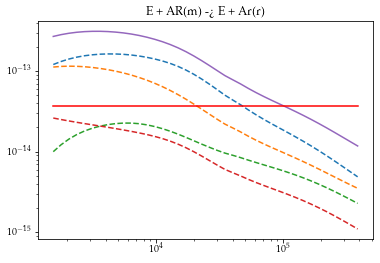

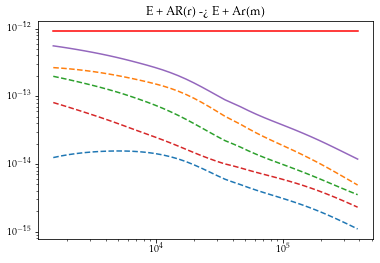

In [87]:
rxn16 = np.zeros(Te.shape)
rxn22 = np.zeros(Te.shape)

sDict = {'Ar5': 'm', 'Ar4': 'r', 'Ar3': 'm', 'Ar2': 'r'}

plt.figure(1)
for c in fwdRates.outputs:
    label = fwdRates.typeDictI2S[c]
    if (fwdRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] not in sDict): continue
        if (collisionDict[label]['product'] not in sDict): continue
        if ((sDict[collisionDict[label]['reactant']] == 'm') and (sDict[collisionDict[label]['product']] == 'r')):
            plt.loglog(Te, fwdRates.outputs[c].data[:,1],'--')
            rxn16 += fwdRates.outputs[c].data[:,1]
            
for c in rvsRates.outputs:
    label = rvsRates.typeDictI2S[c]
    if (rvsRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] not in sDict): continue
        if (collisionDict[label]['product'] not in sDict): continue
        if ((sDict[collisionDict[label]['reactant']] == 'r') and (sDict[collisionDict[label]['product']] == 'm')):
            plt.loglog(Te, rvsRates.outputs[c].data[:,1],'--')
            rxn16 += rvsRates.outputs[c].data[:,1]
            
plt.loglog(Te, rxn16, '-')
plt.loglog(Te, 3.70e-14 * np.ones(Te.shape), '-r')
plt.title('E + AR(m) -> E + Ar(r)')

plt.figure(2)
for c in fwdRates.outputs:
    label = fwdRates.typeDictI2S[c]
    if (fwdRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] not in sDict): continue
        if (collisionDict[label]['product'] not in sDict): continue
        if ((sDict[collisionDict[label]['reactant']] == 'r') and (sDict[collisionDict[label]['product']] == 'm')):
            plt.loglog(Te, fwdRates.outputs[c].data[:,1],'--')
            rxn22 += fwdRates.outputs[c].data[:,1]
            
for c in rvsRates.outputs:
    label = rvsRates.typeDictI2S[c]
    if (rvsRates.outputs[c].collisionType == 'Excitation'):
        if (collisionDict[label]['reactant'] not in sDict): continue
        if (collisionDict[label]['product'] not in sDict): continue
        if ((sDict[collisionDict[label]['reactant']] == 'm') and (sDict[collisionDict[label]['product']] == 'r')):
            plt.loglog(Te, rvsRates.outputs[c].data[:,1],'--')
            rxn22 += rvsRates.outputs[c].data[:,1]
            
plt.loglog(Te, rxn22, '-')
plt.loglog(Te, 9.10e-13 * np.ones(Te.shape), '-r')
plt.title('E + AR(r) -> E + Ar(m)')

In [89]:
import h5py
filename = 'StepwiseExcitations.nominal.h5'
comment = 'Computed with BSR crs dataset at the estimated operation condition of glow discharge.'
with h5py.File(filename, 'w') as f:
    eqn16 = 'E + Ar(m) => E + Ar(r)'
    data16 = np.array([Te, rxn16 * NA]).T
    dset = f.create_dataset(eqn16, data=data16)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment
    
    eqn17 = 'E + Ar(m) => E + Ar(4p)'
    data17 = np.array([Te, rxn17 * NA]).T
    dset = f.create_dataset(eqn17, data=data17)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment
    
    eqn19 = 'E + Ar(4p) => E + Ar(r)'
    data19 = np.array([Te, rxn19 * NA]).T
    dset = f.create_dataset(eqn19, data=data19)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment
    
    eqn20 = 'E + Ar(4p) => E + Ar(m)'
    data20 = np.array([Te, rxn20 * NA]).T
    dset = f.create_dataset(eqn20, data=data20)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment
    
    eqn22 = 'E + Ar(r) => E + Ar(m)'
    data22 = np.array([Te, rxn22 * NA]).T
    dset = f.create_dataset(eqn22, data=data22)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment
    
    eqn23 = 'E + Ar(r) => E + Ar(4p)'
    data23 = np.array([Te, rxn23 * NA]).T
    dset = f.create_dataset(eqn23, data=data23)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Rate coefficient'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comment'] = comment